<a href="https://colab.research.google.com/github/yg36/LangGraph-Learnings/blob/main/Langraph_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Sequential Graph: multiple nodes

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
  name: str
  age: int
  answer: str

In [ ]:
def first_node(state: AgentState)-> AgentState:
  state["answer"] = f"This is first state. "
  return state

def second_node(state: AgentState)->AgentState:
  state["answer"] = state['answer'] + f"This is second state.{state['name']}"
  return state

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("first node", first_node)
graph.add_node("second node", second_node)

graph.set_entry_point("first node")
graph.add_edge("first node", "second node")
graph.set_finish_point("second node")

app = graph.compile()

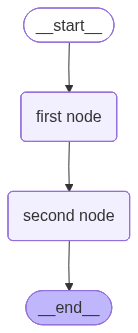

In [ ]:
app

In [ ]:
results = app.invoke({"name": "YG", "age": 67})

In [ ]:
results

{'name': 'YG',
 'age': 67,
 'answer': 'This is first state. This is second state.YG'}